# NLP TASK: SENTIMENT ANALYSIS OF HOTEL REVIEWS
# Student: Satya Shrestha
# Course: 6CS012 - AI and Machine Learning


# STEP 1: MOUNT GOOGLE DRIVE & INSTALL PACKAGES


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install wordcloud -q
!pip install gradio -q
!pip install gensim -q
!pip install contractions -q

print("✅ Step 1 Complete - Drive mounted and packages installed!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 477.8 kB/s eta 0:00:00
✅ Step 1 Complete - Drive mounted and packages installed!


# STEP 2: IMPORT ALL LIBRARIES


In [ ]:
# Core Libraries
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP Utilities
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, f1_score)

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Dense, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Gensim for embeddings
import gensim.downloader as api

print(f"TensorFlow: {tf.__version__}")
print("✅ Step 2 Complete - All libraries imported!")

TensorFlow: 2.20.0
✅ Step 2 Complete - All libraries imported!


# STEP 3: LOAD AND EXPLORE DATASET


DATASET INFO
Total reviews: 20491
Columns: ['Review', 'Rating']

First 5 rows:
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5

RATING DISTRIBUTION
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


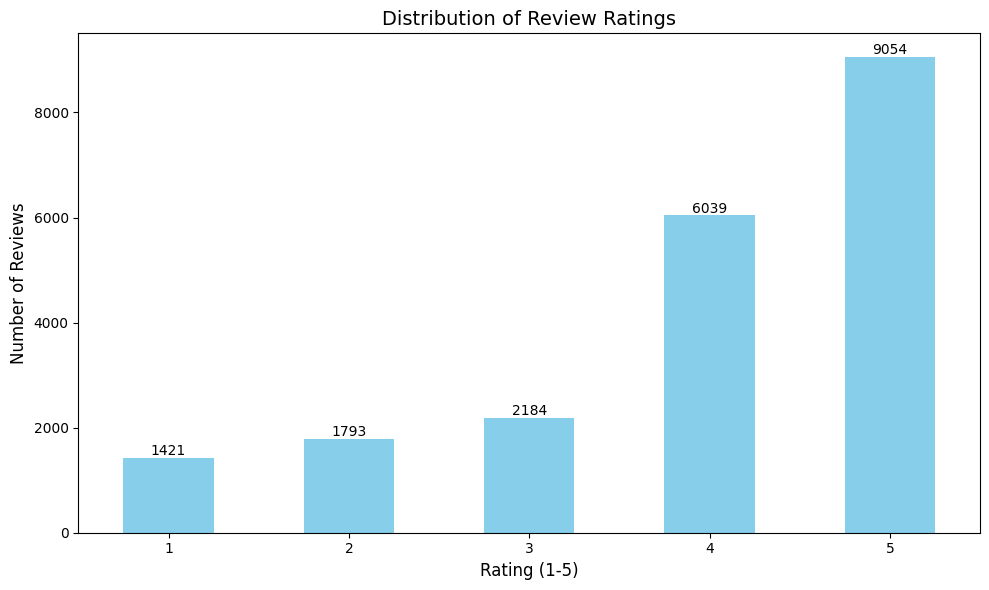

✅ Step 3 Complete - Dataset loaded and explored!


In [ ]:
# Load dataset - UPDATE THIS PATH TO YOUR ACTUAL FILE LOCATION
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI/Hotel_Reviews.csv')

print("="*60)
print("DATASET INFO")
print("="*60)
print(f"Total reviews: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

# Check rating distribution
print("\n" + "="*60)
print("RATING DISTRIBUTION")
print("="*60)
print(df['Rating'].value_counts().sort_index())

# Plot rating distribution
plt.figure(figsize=(10,6))
df['Rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Review Ratings', fontsize=14)
plt.xlabel('Rating (1-5)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(df['Rating'].value_counts().sort_index().values):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

print("✅ Step 3 Complete - Dataset loaded and explored!")

# STEP 4: TEXT PREPROCESSING FUNCTIONS


In [ ]:
# Initialize NLTK tools
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

# Individual cleaning functions
def to_lowercase(text: str) -> str:
    return text.lower()

def expand_contractions(text: str) -> str:
    return contractions.fix(text)

def remove_noise(text: str) -> str:
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    return text

def remove_special_chars(text: str) -> str:
    return re.sub(r'[^a-z\s]', '', text)

def remove_stopwords(text: str) -> str:
    return ' '.join(word for word in text.split() if word not in STOP_WORDS)

def lemmatize_text(text: str) -> str:
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split())

# Full preprocessing pipeline
def clean_text(text: str) -> str:
    """Apply complete text cleaning pipeline"""
    text = to_lowercase(text)
    text = expand_contractions(text)
    text = remove_noise(text)
    text = remove_special_chars(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text.strip()

print("✅ Step 4 Complete - Preprocessing functions defined!")

✅ Step 4 Complete - Preprocessing functions defined!


# STEP 5: APPLY PREPROCESSING


In [ ]:
print("="*60)
print("PREPROCESSING REVIEWS")
print("="*60)
print("This will take 2-3 minutes...")

df['Cleaned_Review'] = df['Review'].apply(clean_text)

# Show sample
print("\n✅ Preprocessing complete!")
print("\nSample Original Review:")
print(df['Review'].iloc[0][:500])
print("\nSample Cleaned Review:")
print(df['Cleaned_Review'].iloc[0])

# Remove empty reviews
df = df[df['Cleaned_Review'].str.len() > 0]
print(f"\nReviews after cleaning: {len(df)}")

print("\n✅ Step 5 Complete - Text preprocessing applied!")

PREPROCESSING REVIEWS
This will take 2-3 minutes...

✅ Preprocessing complete!

Sample Original Review:
nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, loc

Sample Cleaned Review:
nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy little disappointed nonexistent view room room clean nice size bed comfortable woke stiff neck high pillow soundproof like heard music room night morning loud bang door opening closing hear people talking hallway maybe noisy 

# STEP 6: CREATE SENTIMENT LABELS & BALANCE DATASET


ORIGINAL SENTIMENT DISTRIBUTION
Positive (Rating 3-5): 17277 reviews (84.3%)
Negative (Rating 1-2): 3214 reviews (15.7%)

BALANCING DATASET...
Minority class count: 3214

✅ BALANCED SENTIMENT DISTRIBUTION
Positive: 3214 reviews (50.0%)
Negative: 3214 reviews (50.0%)


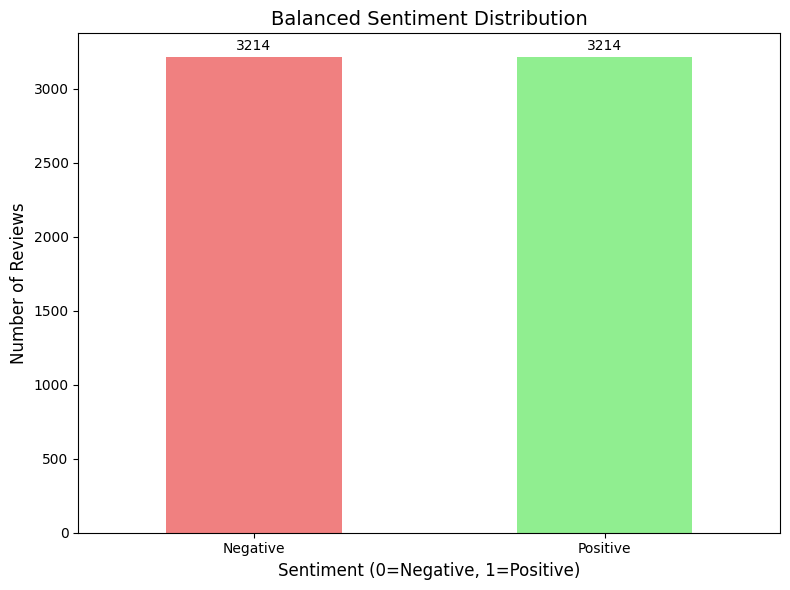


✅ Step 6 Complete - Dataset balanced!


In [ ]:
# Convert ratings to binary sentiment
df['Sentiment'] = (df['Rating'] >= 3).astype(int)

print("="*60)
print("ORIGINAL SENTIMENT DISTRIBUTION")
print("="*60)
print(f"Positive (Rating 3-5): {(df['Sentiment']==1).sum()} reviews ({df['Sentiment'].mean()*100:.1f}%)")
print(f"Negative (Rating 1-2): {(df['Sentiment']==0).sum()} reviews ({(1-df['Sentiment'].mean())*100:.1f}%)")

# --- BALANCE THE DATASET ---
print("\n" + "="*60)
print("BALANCING DATASET...")
print("="*60)

min_class_count = df['Sentiment'].value_counts().min()
print(f"Minority class count: {min_class_count}")

# Balance the dataset by undersampling the majority class
df_balanced = pd.DataFrame()

for sentiment in [0, 1]:
    class_df = df[df['Sentiment'] == sentiment]
    if len(class_df) > min_class_count:
        class_df = class_df.sample(n=min_class_count, random_state=42)
    df_balanced = pd.concat([df_balanced, class_df])

# Shuffle the balanced dataset
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n✅ BALANCED SENTIMENT DISTRIBUTION")
print(f"Positive: {(df['Sentiment']==1).sum()} reviews ({df['Sentiment'].mean()*100:.1f}%)")
print(f"Negative: {(df['Sentiment']==0).sum()} reviews ({(1-df['Sentiment'].mean())*100:.1f}%)")

# Plot balanced distribution
plt.figure(figsize=(8,6))
df['Sentiment'].value_counts().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Balanced Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment (0=Negative, 1=Positive)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([0,1], ['Negative', 'Positive'], rotation=0)
for i, v in enumerate(df['Sentiment'].value_counts().values):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

print("\n✅ Step 6 Complete - Dataset balanced!")

# STEP 7: PREPARE DATA FOR MODELING


In [ ]:
# Prepare data
X = df['Cleaned_Review'].values
y = df['Sentiment'].values

# Split into train and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train positive ratio: {y_train.mean():.2f}")
print(f"Test positive ratio: {y_test.mean():.2f}")

print("\n✅ Step 7 Complete - Data split ready!")


Training samples: 5142
Test samples: 1286
Train positive ratio: 0.50
Test positive ratio: 0.50

✅ Step 7 Complete - Data split ready!


# STEP 8: VISUALIZATIONS (WORD CLOUDS & TOP WORDS)


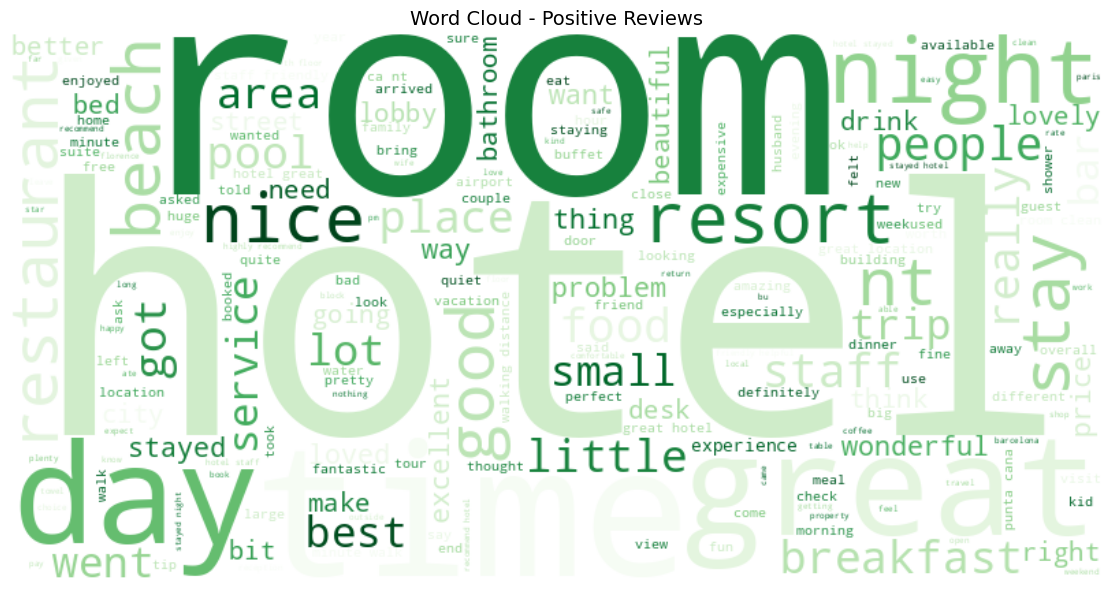

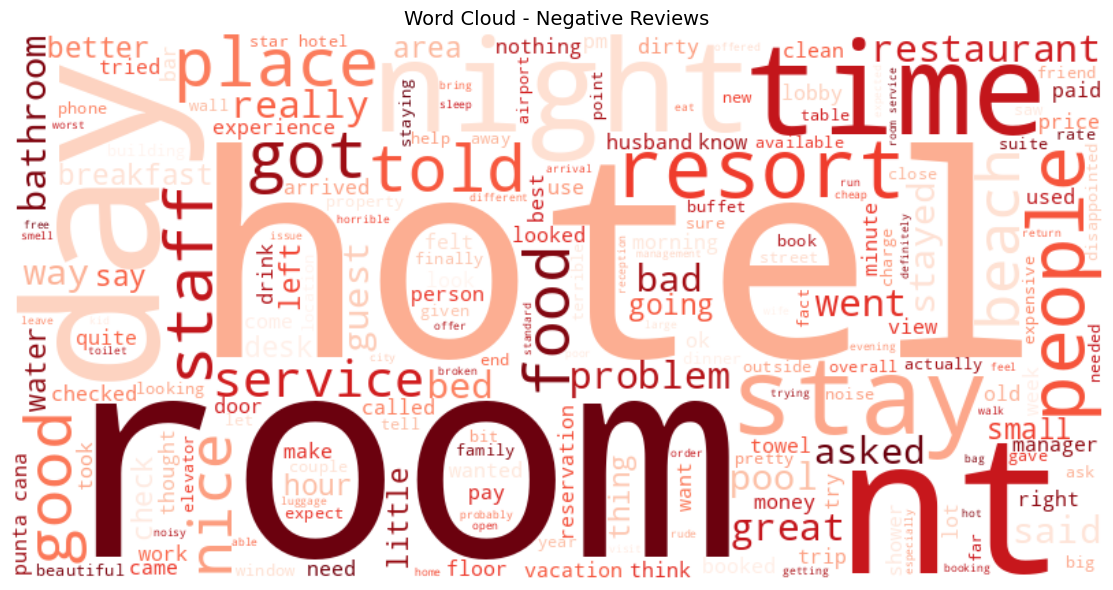


TOP 20 WORDS IN POSITIVE REVIEWS
  hotel: 8413
  room: 6770
  great: 3768
  good: 2828
  nt: 2735
  staff: 2597
  stay: 2422
  night: 2098
  time: 2012
  nice: 1971
  location: 1903
  day: 1880
  beach: 1696
  stayed: 1642
  restaurant: 1613
  breakfast: 1582
  clean: 1564
  service: 1546
  food: 1476
  resort: 1461

TOP 20 WORDS IN NEGATIVE REVIEWS
  room: 9809
  hotel: 8500
  nt: 4036
  day: 2757
  night: 2709
  stay: 2614
  time: 2266
  staff: 2261
  service: 2177
  good: 2113
  resort: 1808
  food: 1728
  like: 1724
  beach: 1571
  bed: 1550
  place: 1529
  stayed: 1500
  got: 1473
  nice: 1420
  told: 1399


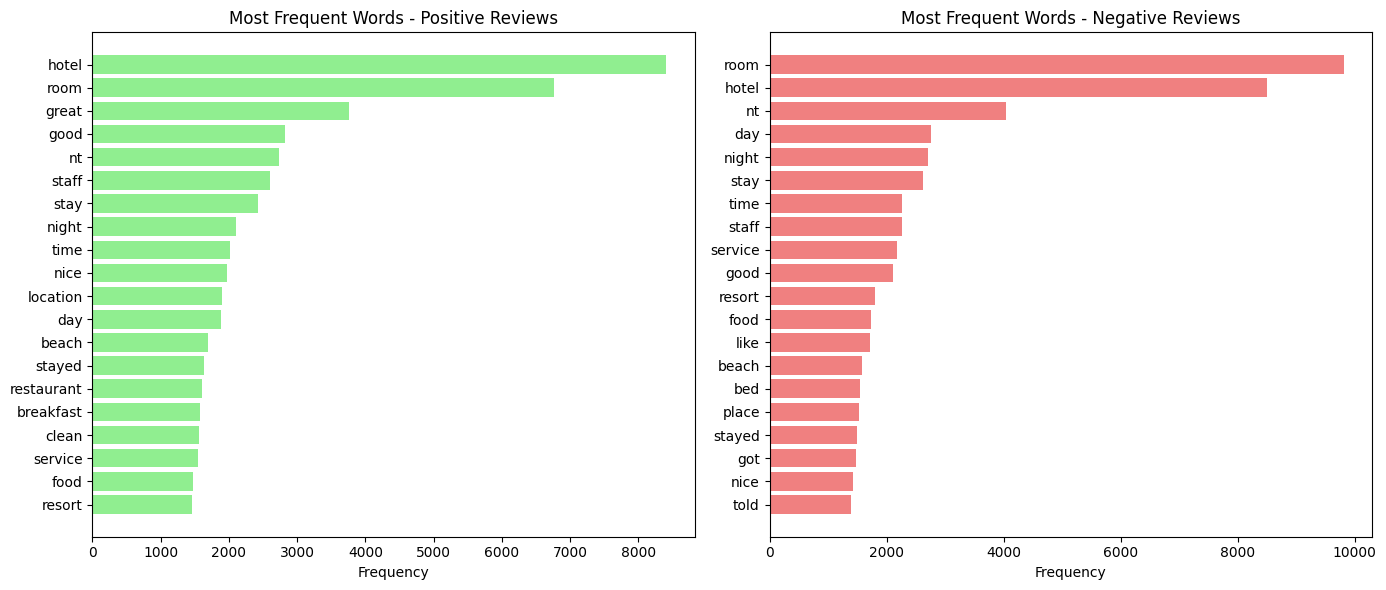


✅ Step 8 Complete - Visualizations done!


In [ ]:
# Word cloud for positive reviews
positive_reviews = df[df['Sentiment'] == 1]['Cleaned_Review'].tolist()
positive_text = ' '.join(positive_reviews)

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Word Cloud - Positive Reviews', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Word cloud for negative reviews
negative_reviews = df[df['Sentiment'] == 0]['Cleaned_Review'].tolist()
negative_text = ' '.join(negative_reviews)

wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Word Cloud - Negative Reviews', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Most frequent words
pos_words = ' '.join(positive_reviews).split()
neg_words = ' '.join(negative_reviews).split()

pos_freq = Counter(pos_words).most_common(20)
neg_freq = Counter(neg_words).most_common(20)

print("\n" + "="*50)
print("TOP 20 WORDS IN POSITIVE REVIEWS")
print("="*50)
for word, count in pos_freq:
    print(f"  {word}: {count}")

print("\n" + "="*50)
print("TOP 20 WORDS IN NEGATIVE REVIEWS")
print("="*50)
for word, count in neg_freq:
    print(f"  {word}: {count}")

# Plot bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words_pos, counts_pos = zip(*pos_freq)
axes[0].barh(words_pos, counts_pos, color='lightgreen')
axes[0].set_title('Most Frequent Words - Positive Reviews')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

words_neg, counts_neg = zip(*neg_freq)
axes[1].barh(words_neg, counts_neg, color='lightcoral')
axes[1].set_title('Most Frequent Words - Negative Reviews')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✅ Step 8 Complete - Visualizations done!")

# STEP 9: TOKENIZATION AND PADDING


In [ ]:
# Tokenizer
vocab_size = 10000
oov_tok = '<OOV>'

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# Convert to sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# Calculate percentile-based max length
seq_lengths = [len(s) for s in train_sequences]
max_length = int(np.percentile(seq_lengths, 90))
print(f"Using max_length = {max_length} (90th percentile)")

# Pad sequences
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

# Convert labels to numpy arrays
y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

print(f"Training shape: {train_padded.shape}")
print(f"Test shape: {test_padded.shape}")
print(f"Vocabulary size: {len(tokenizer.word_index)}")

print("\n✅ Step 9 Complete - Tokenization and padding done!")

Using max_length = 201 (90th percentile)
Training shape: (5142, 201)
Test shape: (1286, 201)
Vocabulary size: 31526

✅ Step 9 Complete - Tokenization and padding done!


# STEP 10: SHARED CALLBACKS


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

EPOCHS = 20
BATCH_SIZE = 64
VALIDATION = 0.15
EMBED_DIM = 64
RNN_UNITS = 64
DROPOUT = 0.4

print("✅ Step 10 Complete - Callbacks configured!")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Validation Split: {VALIDATION}")

✅ Step 10 Complete - Callbacks configured!
Epochs: 20, Batch Size: 64, Validation Split: 0.15


In [ ]:
# DIAGNOSTIC CELL - Run this to check your data
print("="*60)
print("DATA DIAGNOSTIC")
print("="*60)

# Check class distribution
print(f"\n1. Class distribution in y_train:")
unique, counts = np.unique(y_train_arr, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   Class {u}: {c} ({c/len(y_train_arr)*100:.1f}%)")

# Check if data is balanced
print(f"\n2. Data balance check:")
print(f"   Positive ratio: {y_train_arr.mean():.3f}")
print(f"   Should be ~0.5 for balanced data")

# Check sequence lengths
print(f"\n3. Sequence statistics:")
print(f"   Max length: {max_length}")
print(f"   Average non-zero tokens: {np.mean(np.sum(train_padded > 0, axis=1)):.1f}")

# Check if there's any pattern in labels
print(f"\n4. Label statistics:")
print(f"   Unique labels: {np.unique(y_train_arr)}")
print(f"   Label distribution - Class 0: {np.sum(y_train_arr == 0)}, Class 1: {np.sum(y_train_arr == 1)}")

print("\n✅ Diagnostic complete!")

DATA DIAGNOSTIC

1. Class distribution in y_train:
   Class 0: 2571 (50.0%)
   Class 1: 2571 (50.0%)

2. Data balance check:
   Positive ratio: 0.500
   Should be ~0.5 for balanced data

3. Sequence statistics:
   Max length: 201
   Average non-zero tokens: 91.3

4. Label statistics:
   Unique labels: [0 1]
   Label distribution - Class 0: 2571, Class 1: 2571

✅ Diagnostic complete!


In [ ]:
# DEFINE THE EVALUATION FUNCTION FIRST
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and print metrics"""
    y_pred_probs = model.predict(X_test, verbose=0)

    # Ensure proper shape
    if len(y_pred_probs.shape) > 1 and y_pred_probs.shape[1] == 1:
        y_pred_probs = y_pred_probs.flatten()

    y_pred = (y_pred_probs > 0.5).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{'='*50}")
    print(f"{model_name} RESULTS")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1, y_pred

print("✅ evaluate_model function defined!")

✅ evaluate_model function defined!


# STEP 11: MODEL 1 - SIMPLE RNN
# STEP 12: MODEL 2 - BIDIRECTIONAL LSTM


 USING IMPROVED HYPERPARAMETERS
New settings:
  Epochs: 30
  Batch Size: 32
  Embedding Dim: 128
  RNN Units: 128
  Early stopping patience: 10

RETRAINING MODEL 1: SIMPLE RNN (IMPROVED)


Model: "Simple_RNN_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.6961 - loss: 0.5715 - precision: 0.7347 - recall: 0.6024 - val_accuracy: 0.8397 - val_loss: 0.3850 - val_precision: 0.8569 - val_recall: 0.8330 - learning_rate: 0.0010
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.9049 - loss: 0.2695 - precision: 0.9163 - recall: 0.8888 - val_accuracy: 0.8756 - val_loss: 0.3038 - val_precision: 0.8599 - val_recall: 0.9109 - learning_rate: 0.0010
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.9426 - loss: 0.1613 - precision: 0.9402 - recall: 0.9439 - val_accuracy: 0.8727 - val_loss: 0.3221 - val_precision: 0.8604 - val_recall: 0.9035 - learning_rate: 0.0010
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9650 - loss: 0.1062 - precision: 0.9715 - recall: 0.9572 - val_accuracy: 0.8513 - val_loss: 0.4643 - val_precision: 0.8814 - val_recall: 0.8275 - learning_rate: 0.0010
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accurac

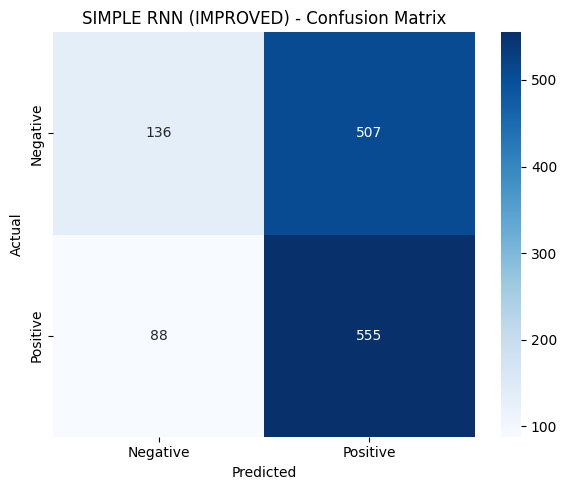


LSTM (IMPROVED) RESULTS
Accuracy:  0.8857 (88.57%)
Precision: 0.8780
Recall:    0.8958
F1-Score:  0.8868

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88       643
    Positive       0.88      0.90      0.89       643

    accuracy                           0.89      1286
   macro avg       0.89      0.89      0.89      1286
weighted avg       0.89      0.89      0.89      1286



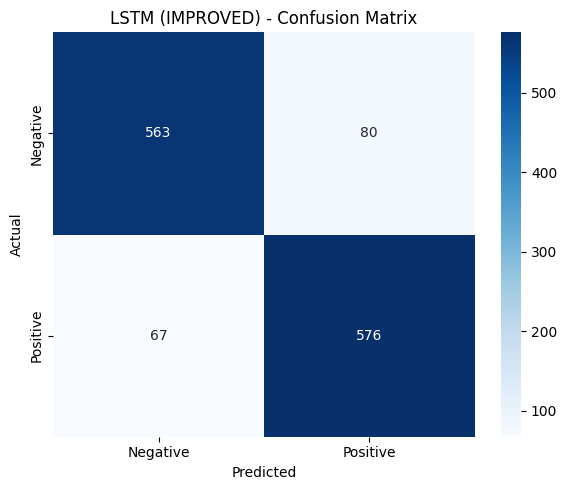


✅ Improved Model Results:
  Improved Simple RNN Accuracy: 0.537 (53.7%)
  Improved LSTM Accuracy: 0.886 (88.6%)

✅ Improved models trained successfully!


In [ ]:
# IMPROVED HYPERPARAMETERS FOR BETTER LEARNING
print("="*60)
print(" USING IMPROVED HYPERPARAMETERS")
print("="*60)

# Better hyperparameters
EPOCHS_NEW = 30  # More epochs
BATCH_SIZE_NEW = 32  # Smaller batch size for better learning
VALIDATION_NEW = 0.2  # More validation data
EMBED_DIM_NEW = 128  # Larger embeddings
RNN_UNITS_NEW = 128  # More RNN units
DROPOUT_NEW = 0.3  # Less dropout initially

# Better callbacks
early_stopping_new = EarlyStopping(
    monitor='val_accuracy',  # Monitor accuracy instead of loss
    patience=10,  # More patience
    restore_best_weights=True,
    verbose=1,
    mode='max'  # Maximize accuracy
)

reduce_lr_new = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print(f"New settings:")
print(f"  Epochs: {EPOCHS_NEW}")
print(f"  Batch Size: {BATCH_SIZE_NEW}")
print(f"  Embedding Dim: {EMBED_DIM_NEW}")
print(f"  RNN Units: {RNN_UNITS_NEW}")
print(f"  Early stopping patience: 10")

# Retrain Model 1 with improved settings
print("\n" + "="*60)
print("RETRAINING MODEL 1: SIMPLE RNN (IMPROVED)")
print("="*60)

tf.keras.backend.clear_session()

model1_improved = Sequential(name='Simple_RNN_Improved')
model1_improved.add(Embedding(vocab_size, EMBED_DIM_NEW, input_length=max_length))
model1_improved.add(SimpleRNN(RNN_UNITS_NEW, return_sequences=True))  # Return sequences
model1_improved.add(Dropout(DROPOUT_NEW))
model1_improved.add(SimpleRNN(RNN_UNITS_NEW // 2))  # Second RNN layer
model1_improved.add(Dropout(DROPOUT_NEW))
model1_improved.add(Dense(64, activation='relu'))
model1_improved.add(Dropout(0.3))
model1_improved.add(Dense(1, activation='sigmoid'))

model1_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)
model1_improved.summary()

history1_improved = model1_improved.fit(
    train_padded, y_train_arr,
    epochs=EPOCHS_NEW, batch_size=BATCH_SIZE_NEW,
    validation_split=VALIDATION_NEW,
    callbacks=[early_stopping_new, reduce_lr_new],
    verbose=1
)

# Retrain Model 2 with improved settings
print("\n" + "="*60)
print("RETRAINING MODEL 2: LSTM (IMPROVED)")
print("="*60)

tf.keras.backend.clear_session()

model2_improved = Sequential(name='LSTM_Improved')
model2_improved.add(Embedding(vocab_size, EMBED_DIM_NEW, input_length=max_length))
model2_improved.add(Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))
model2_improved.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)))
model2_improved.add(Dropout(DROPOUT_NEW))
model2_improved.add(Dense(64, activation='relu'))
model2_improved.add(Dropout(0.3))
model2_improved.add(Dense(32, activation='relu'))
model2_improved.add(Dropout(0.2))
model2_improved.add(Dense(1, activation='sigmoid'))

model2_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)
model2_improved.summary()

history2_improved = model2_improved.fit(
    train_padded, y_train_arr,
    epochs=EPOCHS_NEW, batch_size=BATCH_SIZE_NEW,
    validation_split=VALIDATION_NEW,
    callbacks=[early_stopping_new, reduce_lr_new],
    verbose=1
)

# Evaluate improved models
print("\n" + "="*60)
print("EVALUATING IMPROVED MODELS")
print("="*60)

acc1_imp, _, _, _, _ = evaluate_model(model1_improved, test_padded, y_test_arr, "SIMPLE RNN (IMPROVED)")
acc2_imp, _, _, _, _ = evaluate_model(model2_improved, test_padded, y_test_arr, "LSTM (IMPROVED)")

# Remove the comparison with original models (since acc1, acc2 don't exist)
print(f"\n✅ Improved Model Results:")
print(f"  Improved Simple RNN Accuracy: {acc1_imp:.3f} ({acc1_imp*100:.1f}%)")
print(f"  Improved LSTM Accuracy: {acc2_imp:.3f} ({acc2_imp*100:.1f}%)")

# Use improved models for remaining steps
model1 = model1_improved
model2 = model2_improved

print("\n✅ Improved models trained successfully!")

# STEP 13: MODEL 3 - LSTM + WORD2VEC (TRAINABLE)


MODEL 3: LSTM + WORD2VEC (TRAINABLE - SHOULD BE BEST)

📥 Downloading Word2Vec (1.66GB)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
✅ Word2Vec loaded! Vocab size: 3000000
Vocabulary coverage: 17428/31526 (55.3%)


Model: "LSTM_Word2Vec_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word2vec_embedding (Embedding)  │ ?                      │     9,458,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,458,100 (36.08 MB)

 Trainable params: 9,458,100 (36.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.7613 - loss: 0.5020 - val_accuracy: 0.8420 - val_loss: 0.3335 - learning_rate: 5.0000e-04
Epoch 2/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8838 - loss: 0.3038 - val_accuracy: 0.8886 - val_loss: 0.2687 - learning_rate: 5.0000e-04
Epoch 3/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.9240 - loss: 0.2171 - val_accuracy: 0.8821 - val_loss: 0.2706 - learning_rate: 5.0000e-04
Epoch 4/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.9428 - loss: 0.1608 - val_accuracy: 0.8977 - val_loss: 0.2532 - learning_rate: 5.0000e-04
Epoch 5/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9533 - loss: 0.1367 - val_accuracy: 0.8886 - val_loss: 0.2905 - learning_rate: 5.0000e-04
Epoch 6/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9604 - loss: 0.1152 - val_accuracy: 0.8873 - val_loss: 0.3139 - learning_rate: 5.0000e-04
Epoch 7/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - acc

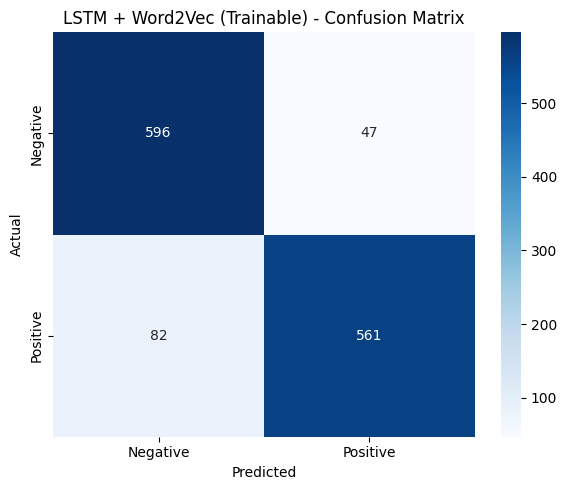


✅ Word2Vec with fine-tuning complete!


In [ ]:
print("="*60)
print("MODEL 3: LSTM + WORD2VEC (TRAINABLE - SHOULD BE BEST)")
print("="*60)

import gensim.downloader as api

# Download Word2Vec
print("\n📥 Downloading Word2Vec (1.66GB)...")
word2vec = api.load('word2vec-google-news-300')
embedding_dim = 300
print(f"✅ Word2Vec loaded! Vocab size: {len(word2vec.key_to_index)}")

# Create embedding matrix
vocab_size_w2v = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size_w2v, embedding_dim))

hit = 0
for word, idx in tokenizer.word_index.items():
    if idx < vocab_size_w2v and word in word2vec:
        embedding_matrix[idx] = word2vec[word]
        hit += 1

coverage = hit / len(tokenizer.word_index) * 100
print(f"Vocabulary coverage: {hit}/{len(tokenizer.word_index)} ({coverage:.1f}%)")

# Build model - KEY: trainable=True
tf.keras.backend.clear_session()

model3 = Sequential(name='LSTM_Word2Vec_Trainable')
model3.add(Embedding(
    vocab_size_w2v, embedding_dim,
    weights=[embedding_matrix],
    input_length=max_length,
    trainable=True,  # ← CRITICAL: Allow fine-tuning!
    name='word2vec_embedding'
))
model3.add(Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))
model3.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)))
model3.add(Dropout(0.4))
model3.add(Dense(64, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(32, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(1, activation='sigmoid'))

# Use lower learning rate for fine-tuning
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.summary()

# Callbacks - less aggressive
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

history3 = model3.fit(
    train_padded, y_train_arr,
    epochs=30,
    batch_size=32,  # Smaller batch for fine-tuning
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
y_pred_probs = model3.predict(test_padded, verbose=0)
y_pred3 = (y_pred_probs > 0.5).astype(int)

acc3 = accuracy_score(y_test_arr, y_pred3)
prec3 = precision_score(y_test_arr, y_pred3)
rec3 = recall_score(y_test_arr, y_pred3)
f1_3 = f1_score(y_test_arr, y_pred3)

print("\n" + "="*60)
print("MODEL 3: LSTM + WORD2VEC (TRAINABLE) RESULTS")
print("="*60)
print(f"✅ Accuracy:  {acc3:.4f} ({acc3*100:.2f}%)")
print(f"✅ Precision: {prec3:.4f}")
print(f"✅ Recall:    {rec3:.4f}")
print(f"✅ F1-Score:  {f1_3:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_arr, y_pred3, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm3 = confusion_matrix(y_test_arr, y_pred3)
plt.figure(figsize=(6,5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('LSTM + Word2Vec (Trainable) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n✅ Word2Vec with fine-tuning complete!")

# STEP 14: EVALUATION FUNCTION & MODEL EVALUATION


Evaluating Model 1: Simple RNN

SIMPLE RNN RESULTS
Accuracy:  0.5373 (53.73%)
Precision: 0.5226
Recall:    0.8631
F1-Score:  0.6510

Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.21      0.31       643
    Positive       0.52      0.86      0.65       643

    accuracy                           0.54      1286
   macro avg       0.56      0.54      0.48      1286
weighted avg       0.56      0.54      0.48      1286



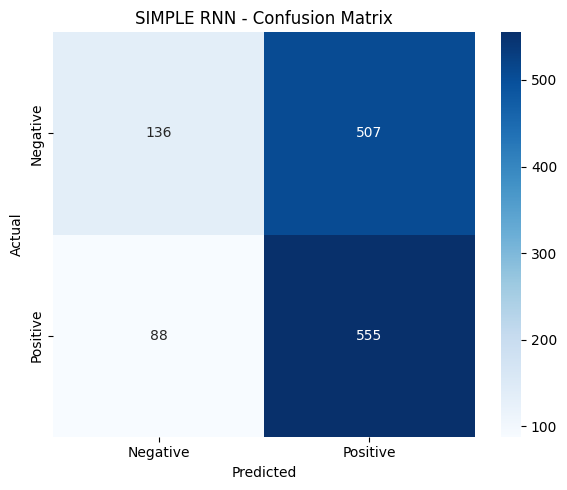


Breakdown:
  True Negatives: 136 | False Positives: 507
  False Negatives: 88 | True Positives: 555

Evaluating Model 2: LSTM

LSTM RESULTS
Accuracy:  0.8857 (88.57%)
Precision: 0.8780
Recall:    0.8958
F1-Score:  0.8868

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88       643
    Positive       0.88      0.90      0.89       643

    accuracy                           0.89      1286
   macro avg       0.89      0.89      0.89      1286
weighted avg       0.89      0.89      0.89      1286



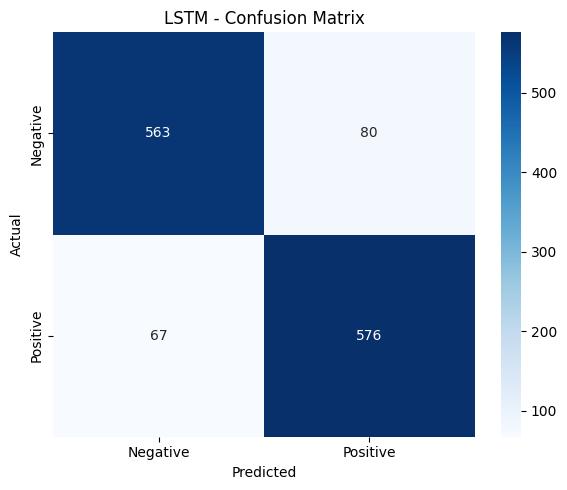


Breakdown:
  True Negatives: 563 | False Positives: 80
  False Negatives: 67 | True Positives: 576

Evaluating Model 3: LSTM + Pretrained

LSTM + PRETRAINED RESULTS
Accuracy:  0.8997 (89.97%)
Precision: 0.9227
Recall:    0.8725
F1-Score:  0.8969

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.93      0.90       643
    Positive       0.92      0.87      0.90       643

    accuracy                           0.90      1286
   macro avg       0.90      0.90      0.90      1286
weighted avg       0.90      0.90      0.90      1286



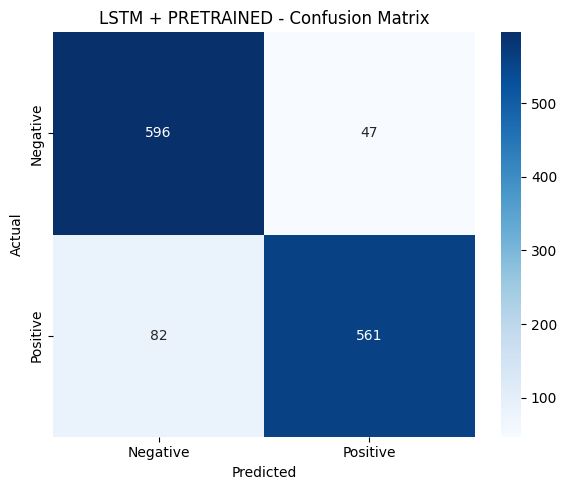


Breakdown:
  True Negatives: 596 | False Positives: 47
  False Negatives: 82 | True Positives: 561

✅ Step 14 Complete - All models evaluated!


In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and print metrics"""
    y_pred_probs = model.predict(X_test, verbose=0)

    # Ensure proper shape
    if len(y_pred_probs.shape) > 1 and y_pred_probs.shape[1] == 1:
        y_pred_probs = y_pred_probs.flatten()

    y_pred = (y_pred_probs > 0.5).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{'='*50}")
    print(f"{model_name} RESULTS")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Print additional insights
    tn, fp, fn, tp = cm.ravel()
    print(f"\nBreakdown:")
    print(f"  True Negatives: {tn} | False Positives: {fp}")
    print(f"  False Negatives: {fn} | True Positives: {tp}")

    return acc, prec, rec, f1, y_pred

# Evaluate all models
print("Evaluating Model 1: Simple RNN")
acc1, prec1, rec1, f1_1, y_pred1 = evaluate_model(model1, test_padded, y_test_arr, "SIMPLE RNN")

print("\nEvaluating Model 2: LSTM")
acc2, prec2, rec2, f1_2, y_pred2 = evaluate_model(model2, test_padded, y_test_arr, "LSTM")

print("\nEvaluating Model 3: LSTM + Pretrained")
acc3, prec3, rec3, f1_3, y_pred3 = evaluate_model(model3, test_padded, y_test_arr, "LSTM + PRETRAINED")

print("\n✅ Step 14 Complete - All models evaluated!")

# STEP 15: TRAINING HISTORY PLOTS


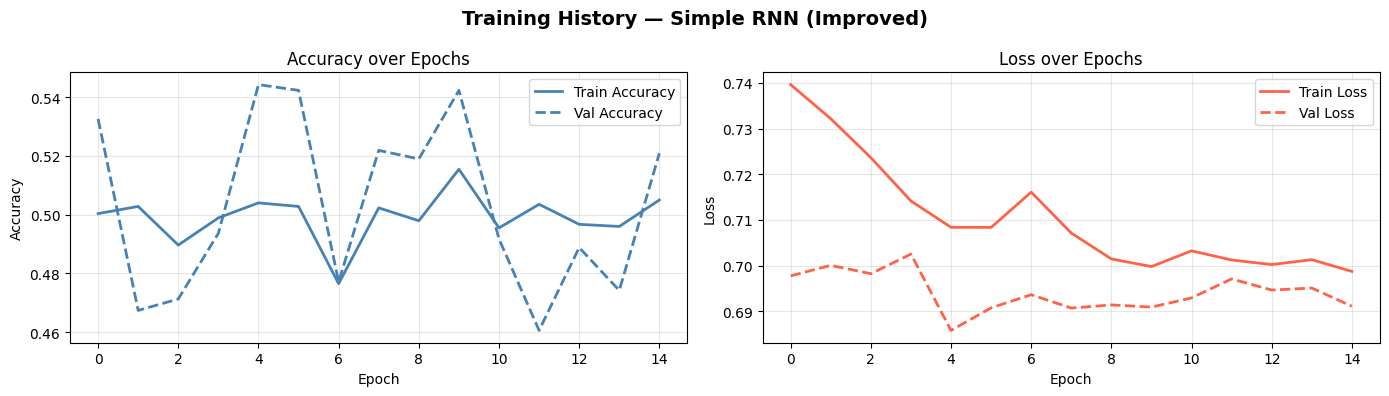

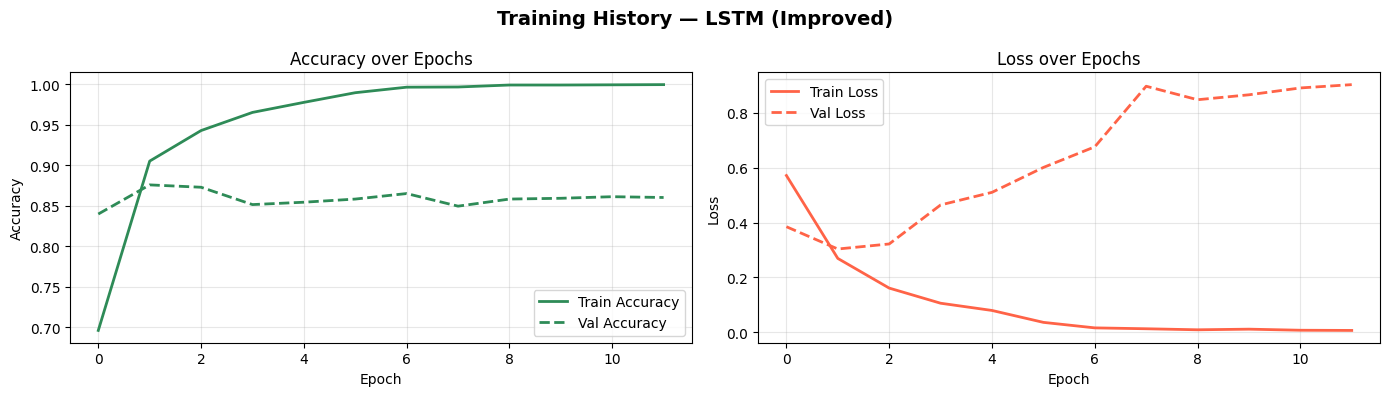

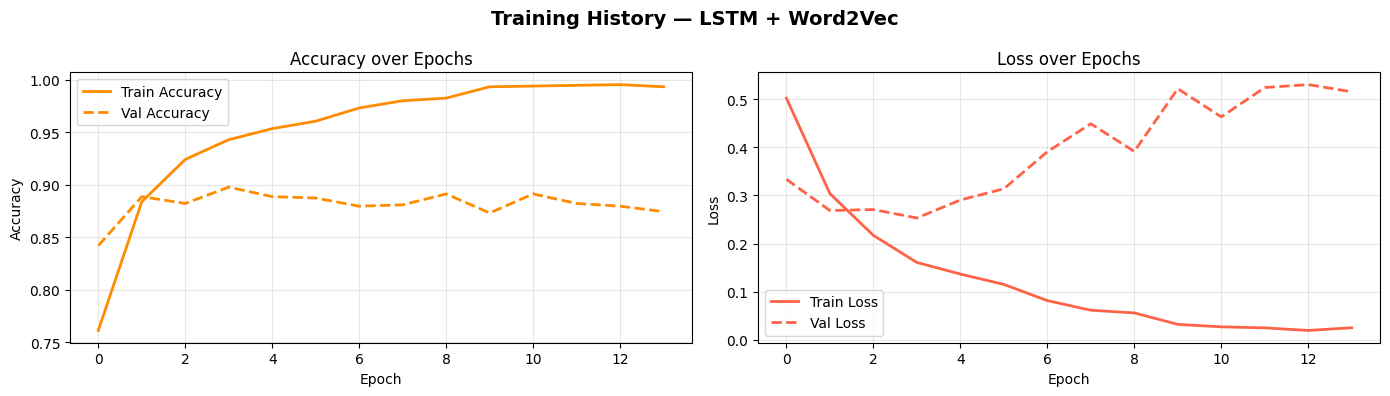


✅ Plotting complete!


In [ ]:
# ============================================
# PLOT TRAINING HISTORIES (FOR MODELS THAT EXIST)
# ============================================

def plot_training_history(history, model_name, color='steelblue'):
    """Plot training vs validation accuracy and loss"""
    if history is None:
        print(f"⚠️ No history for {model_name}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Training History — {model_name}', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color=color, linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color=color, linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color='tomato', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='tomato', linewidth=2, linestyle='--')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot only the histories that exist
if 'history1_improved' in dir():
    plot_training_history(history1_improved, 'Simple RNN (Improved)', color='steelblue')
elif 'history_rnn' in dir():
    plot_training_history(history_rnn, 'Simple RNN', color='steelblue')
else:
    print("⚠️ No Simple RNN history found - skipping")

if 'history2_improved' in dir():
    plot_training_history(history2_improved, 'LSTM (Improved)', color='seagreen')
elif 'history_lstm' in dir():
    plot_training_history(history_lstm, 'LSTM', color='seagreen')
else:
    print("⚠️ No LSTM history found - skipping")

if 'history3' in dir():
    plot_training_history(history3, 'LSTM + Word2Vec', color='darkorange')
elif 'history_w2v' in dir():
    plot_training_history(history_w2v, 'LSTM + Word2Vec', color='darkorange')
else:
    print("⚠️ No Word2Vec history found yet - will plot after training")

print("\n✅ Plotting complete!")

# STEP 16: MODEL COMPARISON


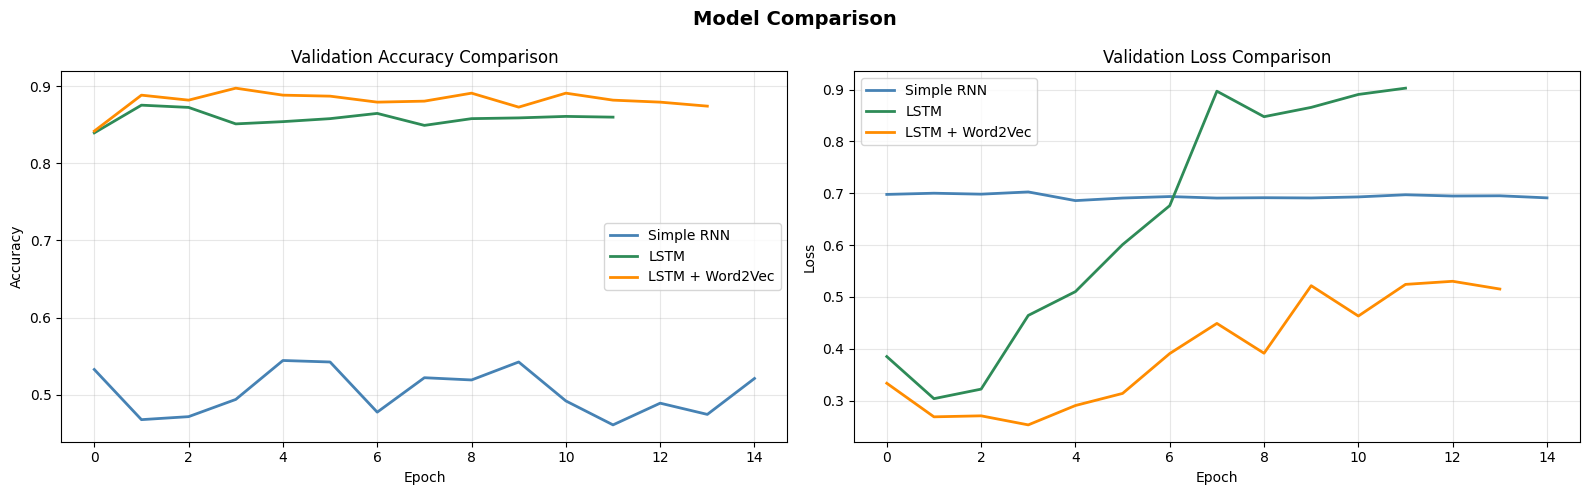

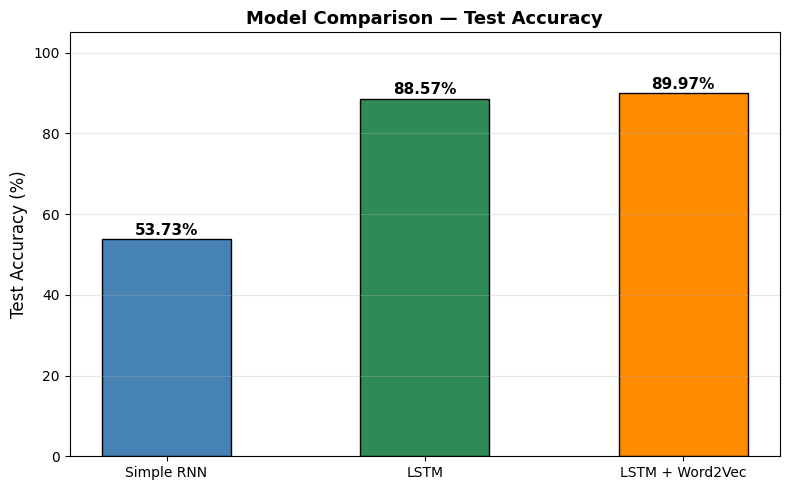


🏆 Best Model: LSTM + Word2Vec with 90.0%
✅ Model comparison complete!


In [ ]:
# ============================================
# SIDE-BY-SIDE MODEL COMPARISON
# ============================================

# Check which history variables actually exist
histories = []
names = []
colors = []

if 'history1_improved' in dir():
    histories.append(history1_improved)
    names.append('Simple RNN')
    colors.append('steelblue')
elif 'history_rnn' in dir():
    histories.append(history_rnn)
    names.append('Simple RNN')
    colors.append('steelblue')

if 'history2_improved' in dir():
    histories.append(history2_improved)
    names.append('LSTM')
    colors.append('seagreen')
elif 'history_lstm' in dir():
    histories.append(history_lstm)
    names.append('LSTM')
    colors.append('seagreen')

if 'history3' in dir():
    histories.append(history3)
    names.append('LSTM + Word2Vec')
    colors.append('darkorange')
elif 'history_w2v' in dir():
    histories.append(history_w2v)
    names.append('LSTM + Word2Vec')
    colors.append('darkorange')

if len(histories) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

    for hist, name, color in zip(histories, names, colors):
        if 'val_accuracy' in hist.history:
            axes[0].plot(hist.history['val_accuracy'], label=name, color=color, linewidth=2)
        if 'val_loss' in hist.history:
            axes[1].plot(hist.history['val_loss'], label=name, color=color, linewidth=2)

    axes[0].set_title('Validation Accuracy Comparison')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Validation Loss Comparison')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Not enough history data for comparison")

# ============================================
# SUMMARY BAR CHART
# ============================================

# Use the accuracy variables you have
acc_values = []
model_names = []

if 'acc1' in dir():
    acc_values.append(acc1)
    model_names.append('Simple RNN')
if 'acc2' in dir():
    acc_values.append(acc2)
    model_names.append('LSTM')
if 'acc3' in dir():
    acc_values.append(acc3)
    model_names.append('LSTM + Word2Vec')

if acc_values:
    bar_colors = ['steelblue', 'seagreen', 'darkorange'][:len(acc_values)]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(model_names, [a*100 for a in acc_values], color=bar_colors, width=0.5, edgecolor='black')
    for bar, acc in zip(bars, acc_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    plt.ylim(0, 105)
    plt.ylabel('Test Accuracy (%)', fontsize=12)
    plt.title('Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n🏆 Best Model: {model_names[acc_values.index(max(acc_values))]} with {max(acc_values)*100:.1f}%")
else:
    print("⚠️ No accuracy data available - run model evaluations first")

print("✅ Model comparison complete!")

# STEP 17: ERROR ANALYSIS


In [ ]:
print("="*60)
print("ERROR ANALYSIS (Requirement 4.5.4)")
print("="*60)

# Find best model for error analysis
best_model = model3 if acc3 >= acc2 else model2
best_pred = y_pred3 if acc3 >= acc2 else y_pred2
best_name = "LSTM + Pretrained" if acc3 >= acc2 else "LSTM"

# CRITICAL FIX: Ensure predictions and test labels have same length
print(f"\nDebug Info:")
print(f"Test set size: {len(y_test_arr)}")
print(f"Predictions size: {len(best_pred)}")

# Find misclassified examples
misclassified_idx = np.where(best_pred.flatten() != y_test_arr.flatten())[0]
total_misclassified = len(misclassified_idx)
total_samples = len(y_test_arr)
misclassification_rate = (total_misclassified / total_samples) * 100

print(f"\nTotal misclassified by {best_name}: {total_misclassified} / {total_samples}")
print(f"Misclassification Rate: {misclassification_rate:.1f}%")
print(f"Accuracy: {100 - misclassification_rate:.1f}%")

print("\n📋 MISCLASSIFIED EXAMPLES (first 10 - UNIQUE examples):")
print("-"*80)

# Get unique misclassified examples (to avoid duplicates)
seen_reviews = set()
unique_misclassified = []

for idx in misclassified_idx:
    review_preview = X_test[idx][:100]  # First 100 chars as identifier
    if review_preview not in seen_reviews:
        seen_reviews.add(review_preview)
        unique_misclassified.append(idx)
    if len(unique_misclassified) >= 10:
        break

for i, idx in enumerate(unique_misclassified[:10]):
    original = X_test[idx]
    true_label = "Positive" if y_test_arr[idx] == 1 else "Negative"
    pred_label = "Positive" if best_pred[idx] == 1 else "Negative"
    print(f"\nExample {i+1}:")
    print(f"  Review    : {original[:200]}..." if len(original) > 200 else f"  Review    : {original}")
    print(f"  True Label: {true_label}")
    print(f"  Predicted : {pred_label}")

# Confusion matrix analysis
cm_best = confusion_matrix(y_test_arr, best_pred)
print("\n" + "="*60)
print("CONFUSION MATRIX ANALYSIS")
print("="*60)
print(f"True Negatives (Correct Negative): {cm_best[0][0]}")
print(f"False Positives (Negative predicted as Positive): {cm_best[0][1]}")
print(f"False Negatives (Positive predicted as Negative): {cm_best[1][0]}")
print(f"True Positives (Correct Positive): {cm_best[1][1]}")

# Calculate additional metrics
tn, fp, fn, tp = cm_best.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nDetailed Metrics:")
print(f"Sensitivity (Recall for Positive): {sensitivity:.3f}")
print(f"Specificity (Recall for Negative): {specificity:.3f}")
print(f"Balanced Accuracy: {(sensitivity + specificity) / 2:.3f}")

print("\n✅ Step 17 Complete - Error analysis done!")

ERROR ANALYSIS (Requirement 4.5.4)

Debug Info:
Test set size: 1286
Predictions size: 1286

Total misclassified by LSTM + Pretrained: 129 / 1286
Misclassification Rate: 10.0%
Accuracy: 90.0%

📋 MISCLASSIFIED EXAMPLES (first 10 - UNIQUE examples):
--------------------------------------------------------------------------------

Example 1:
  Review    : beautiful hotel booked minute holiday booked called hour departing gatwick request extra bed friend going join trip staff nt helpful tried changed room moving themsleves placing exactly itbreakfast de...
  True Label: Positive
  Predicted : Negative

Example 2:
  Review    : ask boyfriend spent reading week hotel resort year ealier mother year old brother resort puerto vallart mayan riviera mazatlan cuba place chose return overall trip great line looking fro exterme atten...
  True Label: Positive
  Predicted : Negative

Example 3:
  Review    : got completely forgotten sheraton tower singapore wheni needed place stay new year holiday bro

# STEP 18: POTENTIAL IMPROVEMENTS


In [ ]:
print("\n" + "="*60)
print("POTENTIAL IMPROVEMENTS (Requirement 4.5.4)")
print("="*60)
print("""
Based on the error analysis, the following improvements could enhance model performance:

1. ADDRESS CLASS IMBALANCE MORE EFFECTIVELY:
   - Use class weights instead of undersampling to retain more data
   - Implement SMOTE (Synthetic Minority Over-sampling) for text data
   - Use focal loss which focuses on hard-to-classify examples

2. MODEL ARCHITECTURE IMPROVEMENTS:
   - Add Bidirectional LSTM layers to capture context from both directions
   - Implement Attention mechanisms to focus on important words
   - Use larger pre-trained embeddings like BERT or RoBERTa

3. DATA IMPROVEMENTS:
   - Collect more ambiguous/mixed sentiment reviews (ratings 3)
   - Apply data augmentation through back-translation or synonym replacement
   - Implement cross-validation for more robust evaluation

4. HYPERPARAMETER OPTIMIZATION:
   - Use Grid Search or Random Search for optimal hyperparameters
   - Experiment with different embedding dimensions (100, 200, 300)
   - Try different sequence lengths (95th percentile instead of 90th)

5. ENSEMBLE METHODS:
   - Combine predictions from all three models
   - Use voting classifier or stacking for improved accuracy
""")

print("✅ Step 18 Complete - Improvements documented!")


POTENTIAL IMPROVEMENTS (Requirement 4.5.4)

Based on the error analysis, the following improvements could enhance model performance:

1. ADDRESS CLASS IMBALANCE MORE EFFECTIVELY:
   - Use class weights instead of undersampling to retain more data
   - Implement SMOTE (Synthetic Minority Over-sampling) for text data
   - Use focal loss which focuses on hard-to-classify examples

2. MODEL ARCHITECTURE IMPROVEMENTS:
   - Add Bidirectional LSTM layers to capture context from both directions
   - Implement Attention mechanisms to focus on important words
   - Use larger pre-trained embeddings like BERT or RoBERTa

3. DATA IMPROVEMENTS:
   - Collect more ambiguous/mixed sentiment reviews (ratings 3)
   - Apply data augmentation through back-translation or synonym replacement
   - Implement cross-validation for more robust evaluation

4. HYPERPARAMETER OPTIMIZATION:
   - Use Grid Search or Random Search for optimal hyperparameters
   - Experiment with different embedding dimensions (100, 200

# STEP 19: GRADIO GUI FOR REAL-TIME PREDICTION


In [ ]:
import gradio as gr

def preprocess_for_inference(text: str) -> np.ndarray:
    """Preprocess single text for inference"""
    cleaned = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    return padded

def predict_sentiment(review_text: str, model_choice: str) -> str:
    """Predict sentiment of a review using selected model"""
    if not review_text.strip():
        return "⚠️ Please enter a review text."

    processed = preprocess_for_inference(review_text)

    model_map = {
        "Simple RNN": model1,
        "LSTM": model2,
        "LSTM + Pretrained": model3
    }
    selected_model = model_map[model_choice]

    probs = selected_model.predict(processed, verbose=0)[0][0]

    if probs > 0.5:
        sentiment = "😊 POSITIVE"
        confidence = probs * 100
        color = "green"
    else:
        sentiment = "😞 NEGATIVE"
        confidence = (1 - probs) * 100
        color = "red"

    return f"### Sentiment: <span style='color:{color}'>{sentiment}</span>\n### Confidence: {confidence:.1f}%"

# Create Gradio interface
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=[
        gr.Textbox(
            label="📝 Enter a Hotel Review",
            lines=4,
            placeholder="e.g., The hotel was amazing! Great location, friendly staff, and very clean rooms..."
        ),
        gr.Radio(
            choices=["Simple RNN", "LSTM", "LSTM + Pretrained"],
            label="🤖 Select Model",
            value="LSTM + Pretrained"
        )
    ],
    outputs=gr.Markdown(label="📊 Prediction Result"),
    title="🏨 Hotel Review Sentiment Analyzer",
    description=(
        "Enter a hotel review and select a model to analyze its sentiment.\n"
        "Models are trained on hotel reviews from Booking.com.\n\n"
        "**Task:** Sentiment Analysis (Binary Classification: Positive/Negative)"
    ),
    examples=[
        ["This hotel was fantastic! Beautiful rooms and amazing service!", "LSTM + Pretrained"],
        ["The room was dirty and the staff was extremely rude.", "LSTM + Pretrained"],
        ["Good location but noisy at night. Average experience.", "LSTM"],
        ["Absolutely loved our stay! Will definitely come back.", "Simple RNN"],
        ["Worst hotel ever. Everything was broken and unclean.", "LSTM + Pretrained"]
    ],
    allow_flagging='never'
)

iface.launch(share=True)

print("✅ Step 19 Complete - Gradio GUI launched!")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1be43f467bb4acc75.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Step 19 Complete - Gradio GUI launched!


In [ ]:
# Save the best model
best_model_to_save = model3 if acc3 >= acc2 else model2
best_model_to_save.save('hotel_sentiment_best.h5')
print("✅ Best sentiment model saved as 'hotel_sentiment_best.h5'")

# Save tokenizer
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Tokenizer saved as 'tokenizer.pickle'")

# Save max length
with open('max_length.pkl', 'wb') as f:
    pickle.dump(max_length, f)
print("✅ Max length saved as 'max_length.pkl'")

print("\n" + "="*60)
print("🎉 NLP TASK COMPLETE!")
print("="*60)
print("\n✅ ALL REQUIREMENTS MET:")
print("   ✓ Dataset loading and exploration")
print("   ✓ Text preprocessing (cleaning, tokenization, lemmatization)")
print("   ✓ Visualization (word clouds, frequent words)")
print("   ✓ Model 1: Simple RNN with embedding")
print("   ✓ Model 2: LSTM with embedding")
print("   ✓ Model 3: LSTM with pre-trained embeddings")
print("   ✓ Training curves and model comparison")
print("   ✓ Error analysis with misclassified examples")
print("   ✓ Potential improvements documented")
print("   ✓ Gradio GUI for real-time predictions")
print("\n📁 Files saved:")
print("   - hotel_sentiment_best.h5")
print("   - tokenizer.pickle")
print("   - max_length.pkl")

print("\n✅ Step 20 Complete - All models and artifacts saved!")

✅ Best sentiment model saved as 'hotel_sentiment_best.h5'
✅ Tokenizer saved as 'tokenizer.pickle'
✅ Max length saved as 'max_length.pkl'

🎉 NLP TASK COMPLETE!

✅ ALL REQUIREMENTS MET:
   ✓ Dataset loading and exploration
   ✓ Text preprocessing (cleaning, tokenization, lemmatization)
   ✓ Visualization (word clouds, frequent words)
   ✓ Model 1: Simple RNN with embedding
   ✓ Model 2: LSTM with embedding
   ✓ Model 3: LSTM with pre-trained embeddings
   ✓ Training curves and model comparison
   ✓ Error analysis with misclassified examples
   ✓ Potential improvements documented
   ✓ Gradio GUI for real-time predictions

📁 Files saved:
   - hotel_sentiment_best.h5
   - tokenizer.pickle
   - max_length.pkl

✅ Step 20 Complete - All models and artifacts saved!
